# Fortnite Vision AI
## Notebook único de ciencia de datos y aprendizaje automático

Compañía ficticia: GameSense Analytics  
Estudiante: [PENDIENTE: completar]  
Profesor: [PENDIENTE: completar]  
Diplomado: [PENDIENTE: completar]  
Fecha: [PENDIENTE: completar]

Este notebook concentra el componente reproducible de datos, preprocesamiento, modelos, evaluación e inferencia. El modo predeterminado es demo: carga artefactos existentes, muestra EDA, ejecuta inferencia sobre un ejemplo y exporta resultados. El entrenamiento, la evaluación final de test, la regeneración de imágenes y la captura de Fortnite están desactivados por defecto.

Ejecutar desde un kernel nuevo y en orden. Google Colab puede ejecutar datos y modelos si las carpetas se montan, pero no puede capturar la ventana de Fortnite del equipo local.

## 1. Descripción del problema, alcance y clases

El sistema integra seis frames, vida y escudo, inventario, mapa y una modalidad de audio representada históricamente por espectrogramas. El objetivo es producir probabilidades para las clases reales Eliminado, Eliminacion y Victoria, y convertir estados observables en recomendaciones explicables.

La auditoría confirma 751 videos originales. Los 26 casos Abajo se mantienen fuera del aprendizaje supervisado por ambigüedad. El alcance es un prototipo académico reproducible conectado conceptualmente con backend, contratos REST/WebSocket y frontend. La captura en vivo es opcional.

In [1]:
# 2. Configuración portable y segura
from pathlib import Path
import os, sys, platform, json, hashlib, time, warnings
from datetime import datetime

ENTORNO="auto"                         # auto | windows_local | colab | linux
RUTA_PROYECTO=Path(r"C:\Users\jonat\Downloads\FORTNITE IA 2")
RUTA_DATOS=Path(r"F:\Cursos\Ciencia de Datos\Modulo 5\CODIGOS\Proyecto Fotnite")
MODO_EJECUCION="demo"                 # demo | completo
USAR_GPU=False
EJECUTAR_ENTRENAMIENTO=False
EJECUTAR_TEST_FINAL=False             # protegido
EJECUTAR_CAPTURA_REAL=False           # protegido
REGENERAR_DATOS_PROCESADOS=False      # protegido
SEMILLA=42
DEMO_MAX_VIDEOS=12

def detectar_entorno():
    if "google.colab" in sys.modules: return "colab"
    return "windows_local" if platform.system()=="Windows" else "linux"
ENTORNO_DETECTADO=detectar_entorno() if ENTORNO=="auto" else ENTORNO
if ENTORNO_DETECTADO=="colab":
    RUTA_PROYECTO=Path(os.environ.get("FORTNITE_RUTA_PROYECTO","/content/FORTNITE IA 2"))
    RUTA_DATOS=Path(os.environ.get("FORTNITE_RUTA_DATOS","/content/Proyecto Fotnite"))
RUTA_VIDEOS,RUTA_DF=RUTA_DATOS/"VIDEOS",RUTA_DATOS/"DF"
RUTA_BACKEND=RUTA_PROYECTO/"backend"
RUTA_SALIDAS_BASE=Path(os.environ.get("FORTNITE_RUTA_SALIDAS",str(RUTA_PROYECTO/"resultados_notebook")))
RUTA_SALIDAS=RUTA_SALIDAS_BASE/datetime.now().strftime("%Y%m%d_%H%M%S")
RUTA_SALIDAS.mkdir(parents=True,exist_ok=True)
np_seed=SEMILLA
print({"entorno":ENTORNO_DETECTADO,"modo":MODO_EJECUCION,"salidas":str(RUTA_SALIDAS),
       "test_protegido":not EJECUTAR_TEST_FINAL,"captura_real":EJECUTAR_CAPTURA_REAL})

{'entorno': 'windows_local', 'modo': 'demo', 'salidas': 'C:\\Users\\jonat\\Downloads\\FORTNITE IA 2\\resultados_notebook\\20260924_185727', 'test_protegido': True, 'captura_real': False}


## 2. Dependencias y reproducibilidad

Dependencias principales: pandas, NumPy, Pillow, scikit-learn, joblib, matplotlib y seaborn. La instalación no se ejecuta automáticamente. Si una librería falta, instalarla manualmente con una celda de pip y volver a ejecutar desde el inicio.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns = None
from PIL import Image, ImageOps, ImageEnhance
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, log_loss
from IPython.display import display, Markdown
if sns is not None: sns.set_theme(style="whitegrid")
np.random.seed(SEMILLA)
try:
    import tensorflow as tf
    tf.random.set_seed(SEMILLA)
    tf_version=tf.__version__
except Exception:
    tf,tf_version=None,"no instalado; el pipeline actual usa scikit-learn"
try:
    import psutil
    memoria_gb=round(psutil.virtual_memory().total/1024**3,2)
except Exception:
    memoria_gb=None
print({"python":sys.version.split()[0],"numpy":np.__version__,"pandas":pd.__version__,
       "tensorflow":tf_version,"cpu":platform.processor(),"memoria_gb":memoria_gb})

{'python': '3.12.10', 'numpy': '2.5.2', 'pandas': '3.0.5', 'tensorflow': 'no instalado; el pipeline actual usa scikit-learn', 'cpu': 'Intel64 Family 6 Model 186 Stepping 2, GenuineIntel', 'memoria_gb': 31.71}


## 3. Auditoría de principal.ipynb

El notebook original se revisa sin modificarlo. Se extraen sus parámetros y se contrasta con manifiestos actuales. La conducta original de borrar carpetas se descarta; la regeneración queda desactivada y, si se activa, escribe solo en una carpeta nueva.

In [3]:
RUTA_PRINCIPAL=RUTA_DATOS/"principal.ipynb"
if RUTA_PRINCIPAL.exists():
    principal=json.loads(RUTA_PRINCIPAL.read_text(encoding="utf-8"))
    resumen_principal=pd.DataFrame([{"celda":i,"tipo":c.get("cell_type"),
        "lineas":len(c.get("source",[])),
        "sha256":hashlib.sha256("".join(c.get("source",[])).encode("utf-8","replace")).hexdigest()[:12]}
        for i,c in enumerate(principal.get("cells",[]))])
    codigo_original="\n".join("".join(c.get("source",[])) for c in principal.get("cells",[]))
    print("Celdas revisadas:",len(resumen_principal)); display(resumen_principal.groupby("tipo").size().rename("cantidad").to_frame())
else:
    resumen_principal=pd.DataFrame(); codigo_original=""
    print("ADVERTENCIA: principal.ipynb no está disponible.")
parametros_originales={
 "posiciones_seis_frames":[.10,.25,.40,.55,.70,.85] if all(x in codigo_original for x in ["0.10","0.25","0.40","0.55","0.70","0.85"]) else None,
 "recortes_por_video":20 if "CANTIDAD_FRAMES = 20" in codigo_original else None,
 "frecuencia_muestreo":32000 if "FRECUENCIA_MUESTREO = 32000" in codigo_original else None,
 "n_mels":128 if "N_MELS = 128" in codigo_original else None,
 "n_fft":2048 if "N_FFT = 2048" in codigo_original else None,
 "hop_length":512 if "HOP_LENGTH = 512" in codigo_original else None}
print(parametros_originales)

Celdas revisadas: 22


,cantidad
tipo,
code,16
markdown,6


{'posiciones_seis_frames': [0.1, 0.25, 0.4, 0.55, 0.7, 0.85], 'recortes_por_video': 20, 'frecuencia_muestreo': 32000, 'n_mels': 128, 'n_fft': 2048, 'hop_length': 512}


### Código recuperado y consolidado desde principal.ipynb

| Componente | Celdas originales | Acción | Sección final |
|---|---:|---|---|
| EDA | 3–7, 13 | Contrastado con reportes actuales | 6–8 |
| Seis frames | 15 | Posiciones confirmadas; no se regenera | 9–10 |
| Mapa, inventario y vida | 16–18 | Se usan recortes existentes | 11–13 |
| Audio | 19 | Parámetros confirmados; runtime puede quedar unavailable | 14 |
| DataFrames | 20–21 | Carga de solo lectura | 5 |

Se revisaron 22 celdas: 16 de código y 6 Markdown.

## 4. Inventario de archivos y modalidades

Se aceptan las variantes AUDIO y AUDIOS. El escaneo es solo de lectura y no altera datos.

In [4]:
def localizar(base,nombres):
    if not base.exists(): return None
    dirs={p.name.upper():p for p in base.iterdir() if p.is_dir()}
    return next((dirs[n.upper()] for n in nombres if n.upper() in dirs),None)
directorios={k:localizar(RUTA_VIDEOS,n) for k,n in {
 "original":["ORIGINAL"],"frames":["FRAMES"],"health":["VIDA"],
 "inventory":["INVENTARIO"],"map":["MAPA"],"audio":["AUDIO","AUDIOS"]}.items()}
display(pd.DataFrame([{"modalidad":k,"ruta":str(v) if v else None,"existe":bool(v)} for k,v in directorios.items()]))
archivos=[]
if RUTA_PROYECTO.exists():
    for p in RUTA_PROYECTO.rglob("*"):
        if p.is_file() and "node_modules" not in p.parts and "__pycache__" not in p.parts:
            archivos.append({"ruta":str(p),"extension":p.suffix.lower(),"bytes":p.stat().st_size})
inventario_archivos=pd.DataFrame(archivos)
print("Archivos inventariados:",len(inventario_archivos))
if not inventario_archivos.empty: display(inventario_archivos["extension"].value_counts().head(15).rename("cantidad").to_frame())
if REGENERAR_DATOS_PROCESADOS:
    print("Regeneración habilitada solo en:",RUTA_SALIDAS/"datos_regenerados")
else: print("Regeneración desactivada: no se sobrescriben resultados.")

,modalidad,ruta,existe
0,original,F:\Cursos\Ciencia de Datos\Modulo 5\CODIGOS\Pr...,True
1,frames,F:\Cursos\Ciencia de Datos\Modulo 5\CODIGOS\Pr...,True
2,health,F:\Cursos\Ciencia de Datos\Modulo 5\CODIGOS\Pr...,True
3,inventory,F:\Cursos\Ciencia de Datos\Modulo 5\CODIGOS\Pr...,True
4,map,F:\Cursos\Ciencia de Datos\Modulo 5\CODIGOS\Pr...,True
5,audio,F:\Cursos\Ciencia de Datos\Modulo 5\CODIGOS\Pr...,True


Archivos inventariados: 180


,cantidad
extension,
.py,38
.md,24
.json,20
.ts,13
.csv,13
,12
.jpg,12
.log,7
.docx,6


Regeneración desactivada: no se sobrescriben resultados.


## 5. Carga y consolidación

Se prefieren los manifiestos y DataFrames actuales. El manifiesto maestro conserva una fila por video y no se utiliza para escribir en las fuentes originales.

In [5]:
def leer_csv(ruta):
    ruta=Path(ruta)
    if not ruta.exists(): return pd.DataFrame()
    try: return pd.read_csv(ruta,encoding="utf-8-sig")
    except UnicodeDecodeError: return pd.read_csv(ruta)
split=leer_csv(RUTA_BACKEND/"data"/"splits"/"video_split.csv")
matriz_modalidades=leer_csv(RUTA_BACKEND/"data"/"manifests"/"modality_matrix.csv")
df_videos=leer_csv(RUTA_DF/"df_videos.csv")
df_frames=leer_csv(RUTA_DF/"df_frames.csv")
df_vida=leer_csv(RUTA_DF/"df_recortes_vida.csv")
df_inventario=leer_csv(RUTA_DF/"df_recortes_inventario.csv")
df_mapa=leer_csv(RUTA_DF/"df_recortes_mapa.csv")
df_audio=leer_csv(RUTA_DF/"df_audio.csv")
print({k:v.shape for k,v in {"split":split,"modalities":matriz_modalidades,"videos":df_videos,
 "frames":df_frames,"health":df_vida,"inventory":df_inventario,"map":df_mapa,"audio":df_audio}.items()})
if split.empty: raise FileNotFoundError("No se encontró video_split.csv; configure RUTA_PROYECTO.")

{'split': (751, 10), 'modalities': (751, 10), 'videos': (751, 4), 'frames': (4506, 9), 'health': (15020, 18), 'inventory': (15020, 18), 'map': (15020, 18), 'audio': (751, 9)}


In [6]:
CLASES={0:"Eliminado",1:"Eliminacion",2:"Victoria"}
tabla_clases=split.groupby(["etiqueta","clase"]).agg(
 videos=("id_video","nunique"),train=("split",lambda s:(s=="train").sum()),
 validation=("split",lambda s:(s=="validation").sum()),test_sellado=("split",lambda s:(s=="test").sum())
).reset_index()
tabla_clases["definicion"]=tabla_clases["clase"].map({
 "Eliminado":"El jugador fue eliminado","Eliminacion":"Evento de eliminación","Victoria":"Victoria"})
tabla_clases["estado"]=np.where(tabla_clases["clase"].isin(CLASES.values()),"confirmada","revisar")
display(tabla_clases)
print("Casos ambiguos excluidos:",int((split["split"]=="excluded_ambiguous").sum()))

,etiqueta,clase,videos,train,validation,test_sellado,definicion,estado
0,0,Eliminado,114,69,27,17,El jugador fue eliminado,confirmada
1,1,Eliminacion,616,412,88,87,Evento de eliminación,confirmada
2,2,Victoria,21,15,3,3,Victoria,confirmada


Casos ambiguos excluidos: 30


## 6. Manifiesto maestro y calidad de rutas

Se consolida una fila por video con disponibilidad y cantidad de muestras. Se trabaja mediante filtros, sin borrar ni sobrescribir originales.

In [7]:
maestro=split.copy()
if not matriz_modalidades.empty:
    cols=[c for c in matriz_modalidades.columns if c=="id_video" or c.endswith("_available")]
    maestro=maestro.merge(matriz_modalidades[cols],on="id_video",how="left",suffixes=("","_matriz"))
for nombre,df in [("frames",df_frames),("health",df_vida),("inventory",df_inventario),("map",df_mapa),("audio",df_audio)]:
    if not df.empty: maestro[nombre+"_muestras"]=maestro["id_video"].map(df.groupby("id_video").size()).fillna(0).astype(int)
for col in ["frames_available","health_available","inventory_available","map_available","audio_available"]:
    if col not in maestro: maestro[col]=False
print("Manifiesto maestro:",maestro.shape); display(maestro.head(3))

Manifiesto maestro: (751, 21)


,id_video,video,ruta_video,clase,etiqueta,group_id,ambiguous_abajo,supervised_eligible,exclusion_reason,split,...,frames_available,health_available,inventory_available,map_available,audio_available,frames_muestras,health_muestras,inventory_muestras,map_muestras,audio_muestras
0,1,Fortnite 2026.08.06 - 17.51.47.62.Eliminación....,F:\Cursos\Ciencia de Datos\Modulo 5\CODIGOS\Pr...,Eliminacion,1,1,False,True,NaN,train,...,True,True,True,True,True,6,20,20,20,1
1,2,Fortnite 2025.11.09 - 17.12.38.74.Victoria.DVR...,F:\Cursos\Ciencia de Datos\Modulo 5\CODIGOS\Pr...,Victoria,2,2,False,True,NaN,train,...,True,True,True,True,True,6,20,20,20,1
2,3,Fortnite 2025.12.11 - 21.10.08.08.Eliminación....,F:\Cursos\Ciencia de Datos\Modulo 5\CODIGOS\Pr...,Eliminacion,1,3,False,True,NaN,test,...,True,True,True,True,True,6,20,20,20,1


In [8]:
def calidad_rutas(nombre,df,col):
    if df.empty or col not in df: return {"modalidad":nombre,"registros":0,"rutas_existentes":None}
    rutas=df[col].dropna().astype(str)
    return {"modalidad":nombre,"registros":len(df),"rutas_unicas":rutas.nunique(),"rutas_existentes":sum(Path(x).exists() for x in rutas)}
calidad=pd.DataFrame([calidad_rutas(*x) for x in [("frames",df_frames,"ruta_imagen"),("health",df_vida,"ruta_vida"),("inventory",df_inventario,"ruta_inventario"),("map",df_mapa,"ruta_mapa"),("audio",df_audio,"ruta_espectrograma")]])
display(calidad)
print("Duplicados exactos reportados:",len(leer_csv(RUTA_BACKEND/"data"/"manifests"/"duplicate_groups.csv")))

,modalidad,registros,rutas_unicas,rutas_existentes
0,frames,4506,4506,4506
1,health,15020,15020,15020
2,inventory,15020,15020,15020
3,map,15020,15020,15020
4,audio,751,751,751


Duplicados exactos reportados: 74


## 7. Análisis exploratorio

Se muestran distribución de clases, disponibilidad, estadísticas numéricas y calidad de rutas.

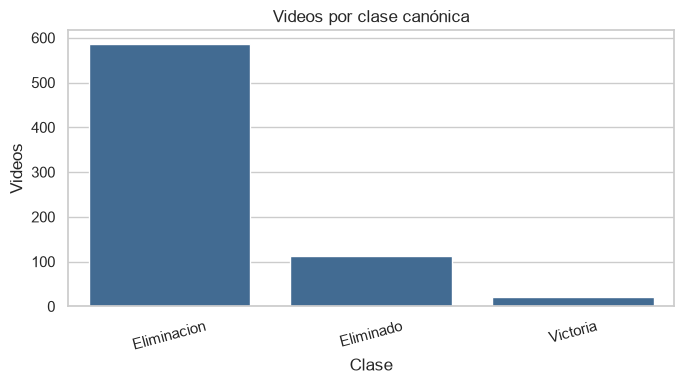

,videos
clase,
Eliminacion,587
Eliminado,113
Victoria,21


In [9]:
base_eda=split[split["split"].isin(["train","validation","test"])]
plt.figure(figsize=(7,4)); sns.countplot(data=base_eda,x="clase",order=["Eliminacion","Eliminado","Victoria"],color="#356B9F")
plt.title("Videos por clase canónica"); plt.xlabel("Clase"); plt.ylabel("Videos"); plt.xticks(rotation=15); plt.tight_layout(); plt.show()
display(base_eda.groupby("clase").size().rename("videos").to_frame())

La clase Eliminacion es mayoritaria y Victoria es minoritaria. El soporte pequeño de Victoria en validation limita la interpretación de su F1.

,Unnamed: 0,count,mean,std,min,25%,50%,75%,max
0,duration_sec,751.0,19.604248,2.375959,12.48,20.03,20.22,20.38,29.28
1,fps,751.0,60.000000,0.000000,60.00,60.00,60.00,60.00,60.00
2,width,751.0,1360.000000,0.000000,1360.00,1360.00,1360.00,1360.00,1360.00
3,height,751.0,768.000000,0.000000,768.00,768.00,768.00,768.00,768.00


,videos_disponibles
original_video_available,751
frames_available,751
health_available,751
inventory_available,751
map_available,751
audio_available,751


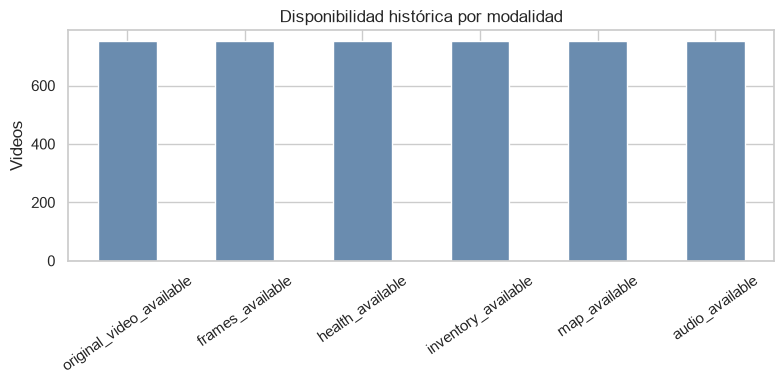

In [10]:
numeric=leer_csv(RUTA_BACKEND/"reports"/"eda"/"numeric_summary.csv")
if not numeric.empty: display(numeric)
availability=maestro[[c for c in maestro.columns if c.endswith("_available")]].fillna(False).astype(bool).sum().rename("videos_disponibles")
display(availability.to_frame())
availability.plot(kind="bar",figsize=(8,4),color="#6A8CAF",title="Disponibilidad histórica por modalidad")
plt.ylabel("Videos"); plt.xticks(rotation=35); plt.tight_layout(); plt.show()

La auditoría reporta 751 videos por modalidad histórica, 60 FPS y resolución 1360×768. Audio puede quedar unavailable en vivo aunque existan espectrogramas históricos.

In [11]:
calidad_limpieza=pd.DataFrame({"control":["videos en manifiesto","supervisados","excluidos","imágenes corruptas reportadas","errores ffprobe reportados"],"valor":[len(maestro),len(maestro[maestro.split.isin(["train","validation","test"])]),int((maestro.split=="excluded_ambiguous").sum()),0,0]})
display(calidad_limpieza)

,control,valor
0,videos en manifiesto,751
1,supervisados,721
2,excluidos,30
3,imágenes corruptas reportadas,0
4,errores ffprobe reportados,0


## 8. Limpieza y separación por video

La separación vigente usa id_video. Se verifica que ningún video aparezca en dos grupos y que test permanezca separado.

In [12]:
grupos={s:set(split.loc[split["split"]==s,"id_video"].astype(int)) for s in ["train","validation","test","excluded_ambiguous"]}
inter={a+"_"+b:len(grupos[a]&grupos[b]) for a in grupos for b in grupos if a<b}
print("Intersecciones:",inter); assert all(v==0 for v in inter.values()),"Fuga detectada"
display(split.groupby(["split","clase"]).size().rename("videos").to_frame())
print("Test protegido:",not EJECUTAR_TEST_FINAL)

Intersecciones: {'train_validation': 0, 'test_train': 0, 'test_validation': 0, 'excluded_ambiguous_train': 0, 'excluded_ambiguous_validation': 0, 'excluded_ambiguous_test': 0}


videos
split              clase              
excluded_ambiguous Eliminacion      29
                   Eliminado         1
test               Eliminacion      87
                   Eliminado        17
                   Victoria          3
train              Eliminacion     412
                   Eliminado        69
                   Victoria         15
validation         Eliminacion      88
                   Eliminado        27
                   Victoria          3

Test protegido: True


## 9. Preprocesamiento de imágenes y secuencias

Se reproduce el preprocesamiento vigente: RGB, resize 16x16 y float32/255. Los seis frames usan 10 %, 25 %, 40 %, 55 %, 70 % y 85 %. Las funciones no modifican archivos.

In [13]:
IMAGE_SIZE=(16,16); MODALIDADES=("frames","health","inventory","map","audio"); NOMBRES_CLASES=["Eliminado","Eliminacion","Victoria"]
def image_feature(path):
    with Image.open(path) as im:
        im=ImageOps.exif_transpose(im).convert("RGB").resize(IMAGE_SIZE)
        return (np.asarray(im,dtype=np.float32)/255.).reshape(-1)
def crops_feature(paths):
    m=np.vstack([image_feature(p) for p in paths]); return np.concatenate([m.mean(0),m.std(0)]).reshape(1,-1)
def sequence_feature(paths):
    v=[image_feature(p) for p in list(paths)[:6]]
    if not v: raise ValueError("Secuencia sin frames")
    v += [np.zeros_like(v[0])]*(6-len(v)); return np.concatenate(v).reshape(1,-1)
def modality_feature(df,col,video_id,sequence=False):
    sub=df[df["id_video"].astype(int)==int(video_id)].copy()
    if sub.empty:return None
    order=next((c for c in sub.columns if c.endswith("_orden")),None)
    if order:sub=sub.sort_values(order)
    paths=[p for p in sub[col].astype(str) if Path(p).exists()]
    if not paths:return None
    return sequence_feature(paths) if sequence else crops_feature(paths)
print("Preprocesamiento listo:",IMAGE_SIZE)

Preprocesamiento listo: (16, 16)


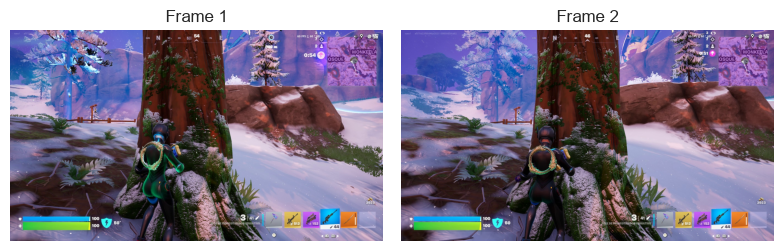

Ejemplo: 21


In [14]:
ejemplo_id=int(split.loc[split["split"]=="validation","id_video"].iloc[0])
rows=df_frames[df_frames["id_video"].astype(int)==ejemplo_id].sort_values("frame_orden").head(2)
fig,axs=plt.subplots(1,2,figsize=(8,3))
for ax,(_,r) in zip(axs,rows.iterrows()):
    if Path(r["ruta_imagen"]).exists(): ax.imshow(Image.open(r["ruta_imagen"]))
    ax.set_title("Frame "+str(r["frame_orden"])); ax.axis("off")
plt.tight_layout(); plt.show(); print("Ejemplo:",ejemplo_id)

## 10. Aumento y balanceo

El reporte de splits confirma que no se aplicó aumentación. Los baselines actuales usan class_weight='balanced'. La función siguiente es opcional y solo sería válida para train.

In [15]:
def aumento_opcional(imagen,angulo=0,brillo=1.0,contraste=1.0):
    imagen=imagen.rotate(angulo,resample=Image.Resampling.BILINEAR)
    imagen=ImageEnhance.Brightness(imagen).enhance(brillo)
    return ImageEnhance.Contrast(imagen).enhance(contraste)
print("Aumentación ejecutada:",False)
print("Balanceo de entrenamiento: class_weight='balanced'.")

Aumentación ejecutada: False
Balanceo de entrenamiento: class_weight='balanced'.


## 11. Baselines independientes

Los artefactos vigentes son LogisticRegression baseline-0.2.0 para frames, health, inventory, map y audio. En demo se cargan; el entrenamiento desde cero requiere activar el control en modo completo.

In [16]:
DATASETS={"frames":(df_frames,"ruta_imagen",True),"health":(df_vida,"ruta_vida",False),"inventory":(df_inventario,"ruta_inventario",False),"map":(df_mapa,"ruta_mapa",False),"audio":(df_audio,"ruta_espectrograma",False)}
RUTA_ARTIFACTOS=RUTA_BACKEND/"artifacts"/"baselines"; modelos_baseline={}
for m in MODALIDADES:
    p=RUTA_ARTIFACTOS/(m+"_logistic.joblib")
    if p.exists():
        obj=joblib.load(p); modelos_baseline[m]=obj["model"] if isinstance(obj,dict) and "model" in obj else obj
print("Baselines cargados:",list(modelos_baseline))
baseline_json=RUTA_BACKEND/"reports"/"baselines"/"baseline_metrics.json"
baseline_report=json.loads(baseline_json.read_text(encoding="utf-8")) if baseline_json.exists() else {}
metricas_baseline=pd.DataFrame([{"modelo":m,"modalidad":m,"split":"validation",**v.get("validation",{})} for m,v in baseline_report.get("modalities",{}).items()])
display(metricas_baseline)

Baselines cargados: ['frames', 'health', 'inventory', 'map', 'audio']


,modelo,modalidad,split,samples,f1_macro,balanced_accuracy,log_loss
0,frames,frames,validation,118,0.863524,0.885101,0.321492
1,health,health,validation,118,0.793163,0.869949,0.128411
2,inventory,inventory,validation,118,0.853869,0.865180,0.158701
3,map,map,validation,118,0.942489,0.992424,0.140061
4,audio,audio,validation,118,0.860755,0.944024,0.400756


In [17]:
def aggregate_rows(df,col,ids,sequence=False):
    X=[]; used=[]
    for vid in ids:
        x=modality_feature(df,col,vid,sequence)
        if x is not None: X.append(x.ravel()); used.append(int(vid))
    return np.vstack(X),np.asarray(used,dtype=int)
def entrenar_baselines():
    labels=dict(zip(split.id_video.astype(int),split.etiqueta.astype(int))); tr=split.loc[split.split=="train","id_video"].astype(int); va=split.loc[split.split=="validation","id_video"].astype(int); out={}; rows=[]
    for m,(df,col,seq) in DATASETS.items():
        Xtr,itr=aggregate_rows(df,col,tr,seq); Xv,iv=aggregate_rows(df,col,va,seq); ytr=np.array([labels[x] for x in itr]); yv=np.array([labels[x] for x in iv])
        model=LogisticRegression(max_iter=500,class_weight="balanced",random_state=SEMILLA).fit(Xtr,ytr); p=model.predict_proba(Xv); pred=model.classes_[p.argmax(1)]
        rows.append({"modelo":m,"modalidad":m,"split":"validation","samples":len(yv),"accuracy":accuracy_score(yv,pred),"macro_f1":f1_score(yv,pred,average="macro",zero_division=0),"balanced_accuracy":balanced_accuracy_score(yv,pred),"log_loss":log_loss(yv,p,labels=[0,1,2])}); out[m]=model
    return out,pd.DataFrame(rows)
if EJECUTAR_ENTRENAMIENTO and MODO_EJECUCION=="completo":
    modelos_baseline,metricas_entrenadas=entrenar_baselines(); display(metricas_entrenadas)
else: print("Entrenamiento desactivado; se conservan artefactos existentes.")

Entrenamiento desactivado; se conservan artefactos existentes.


## 12. Modelo de seis frames y 13–17. Modalidades

El modelo de frames es un baseline de vector concatenado; no se encontró evidencia de CNN-LSTM implementada. Vida/escudo, inventario y mapa usan recortes agregados. Audio usa espectrogramas históricos: 32 kHz, Mel 128, FFT 2048 y hop 512; el runtime real puede publicar unavailable.

In [18]:
tabla_modalidades=pd.DataFrame([
 {"modalidad":"frames","entrada":"seis imágenes","transformación":"vector concatenado 16x16 RGB","estado":"baseline cargable"},
 {"modalidad":"health","entrada":"recortes vida/escudo","transformación":"media y desviación","estado":"baseline + lector runtime"},
 {"modalidad":"inventory","entrada":"20 recortes por video","transformación":"media y desviación; cinco espacios runtime","estado":"baseline + estructura"},
 {"modalidad":"map","entrada":"20 recortes por video","transformación":"media y desviación","estado":"baseline + estado runtime"},
 {"modalidad":"audio","entrada":"espectrograma PNG","transformación":"32 kHz; Mel 128; FFT 2048; hop 512","estado":"baseline histórico; runtime unavailable"}])
display(tabla_modalidades); print("Posiciones:",parametros_originales.get("posiciones_seis_frames"))

,modalidad,entrada,transformación,estado
0,frames,seis imágenes,vector concatenado 16x16 RGB,baseline cargable
1,health,recortes vida/escudo,media y desviación,baseline + lector runtime
2,inventory,20 recortes por video,media y desviación; cinco espacios runtime,baseline + estructura
3,map,20 recortes por video,media y desviación,baseline + estado runtime
4,audio,espectrograma PNG,32 kHz; Mel 128; FFT 2048; hop 512,baseline histórico; runtime unavailable


Posiciones: [0.1, 0.25, 0.4, 0.55, 0.7, 0.85]


## 18. Variables tabulares, máscaras y 19. Fusión multimodal

El modelo principal combina probabilidades de cinco baselines y cinco máscaras de disponibilidad. Las entradas faltantes se representan con ceros y máscara cero. La fusión vigente es LogisticRegression multimodal-0.1.0; el promedio de probabilidades con pesos iguales es baseline separado.

In [19]:
feature_names=[m+".p_"+c for m in MODALIDADES for c in NOMBRES_CLASES]+["available."+m for m in MODALIDADES]
RUTA_FUSION=RUTA_BACKEND/"artifacts"/"multimodal"/"fusion_model.joblib"
fusion_obj=joblib.load(RUTA_FUSION) if RUTA_FUSION.exists() else None
fusion_model=fusion_obj.get("model") if isinstance(fusion_obj,dict) and "model" in fusion_obj else fusion_obj
multi_json=RUTA_BACKEND/"reports"/"multimodal"/"MULTIMODAL_REPORT.json"
multimodal_report=json.loads(multi_json.read_text(encoding="utf-8")) if multi_json.exists() else {}
print("Variables:",len(feature_names),"fusion cargada:",fusion_model is not None,"test usado:",multimodal_report.get("test_used"))

Variables: 20 fusion cargada: True test usado: False


In [20]:
def construir_caracteristicas_multimodales(ids):
    rows=[]
    for vid in ids:
        values=[]; available=[]
        for m,(df,col,seq) in DATASETS.items():
            x=modality_feature(df,col,vid,seq)
            if x is None or m not in modelos_baseline: values += [0.,0.,0.]; available.append(0.)
            else: values += modelos_baseline[m].predict_proba(x)[0].tolist(); available.append(1.)
        rows.append(values+available)
    return np.asarray(rows,dtype=np.float32)
print("Constructor multimodal listo.")

Constructor multimodal listo.


## 20. Evaluación y 21. Comparación

Por defecto se muestran métricas de validation existentes. El test no se usa para seleccionar, calibrar, ajustar hiperparámetros ni elegir umbrales. EJECUTAR_TEST_FINAL=False muestra que la evaluación final no se realizó.

,modelo,split,samples,macro_f1,weighted_f1,balanced_accuracy,log_loss,latencia_ms
0,logistic,validation,118.0,0.992035,0.991578,0.996212,0.058481,0.001125
1,gradient_boosting,validation,118.0,0.655395,0.773221,0.638187,0.362494,0.018807
2,weighted_average,validation,NaN,0.992035,NaN,0.996212,0.154808,0.000000


**Conjunto test reservado. No se realizó la evaluación final.**

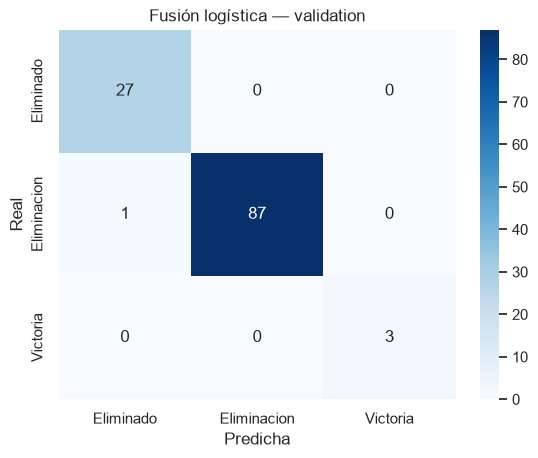

In [21]:
def tabla_multi(report):
    return pd.DataFrame([{"modelo":k,"split":"validation","samples":v.get("samples"),"macro_f1":v.get("f1_macro"),"weighted_f1":v.get("f1_weighted"),"balanced_accuracy":v.get("balanced_accuracy"),"log_loss":v.get("log_loss"),"latencia_ms":v.get("mean_latency_ms")} for k,v in report.get("candidates",{}).items()])
display(tabla_multi(multimodal_report))
if not EJECUTAR_TEST_FINAL: display(Markdown("**Conjunto test reservado. No se realizó la evaluación final.**"))
met_log=multimodal_report.get("candidates",{}).get("logistic",{}); cm=np.asarray(met_log.get("confusion_matrix",[]))
if cm.size:
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=NOMBRES_CLASES,yticklabels=NOMBRES_CLASES); plt.title("Fusión logística — validation"); plt.xlabel("Predicha"); plt.ylabel("Real"); plt.show()

In [22]:
bench_path=RUTA_BACKEND/"reports"/"performance"/"inference_benchmark.json"
benchmark=json.loads(bench_path.read_text(encoding="utf-8")) if bench_path.exists() else {}
filas=[]
for m,v in baseline_report.get("modalities",{}).items(): filas.append({"modelo":m,"modalidad":m,"split":"validation","macro_f1":v.get("validation",{}).get("f1_macro"),"weighted_f1":"no reportado","latencia_ms":benchmark.get(m,{}).get("mean_ms"),"estado":"baseline-0.2.0"})
for m,v in multimodal_report.get("candidates",{}).items(): filas.append({"modelo":m,"modalidad":"multimodal","split":"validation","macro_f1":v.get("f1_macro"),"weighted_f1":v.get("f1_weighted"),"latencia_ms":v.get("mean_latency_ms"),"estado":"candidate"})
comparacion=pd.DataFrame(filas); display(comparacion)

,modelo,modalidad,split,macro_f1,weighted_f1,latencia_ms,estado
0,frames,frames,validation,0.863524,no reportado,NaN,baseline-0.2.0
1,health,health,validation,0.793163,no reportado,NaN,baseline-0.2.0
2,inventory,inventory,validation,0.853869,no reportado,NaN,baseline-0.2.0
3,map,map,validation,0.942489,no reportado,NaN,baseline-0.2.0
4,audio,audio,validation,0.860755,no reportado,NaN,baseline-0.2.0
5,logistic,multimodal,validation,0.992035,0.991578,0.001125,candidate
6,gradient_boosting,multimodal,validation,0.655395,0.773221,0.018807,candidate
7,weighted_average,multimodal,validation,0.992035,None,0.000000,candidate


## 22. Inferencia sobre un ejemplo de validation

Se muestran probabilidades independientes, predicción multimodal, clase real y confianza. La etiqueta real solo contextualiza el ejemplo.

In [23]:
def inferir_ejemplo(video_id):
    salida={"id_video":int(video_id),"clase_real":str(split.loc[split.id_video==video_id,"clase"].iloc[0]),"modalidades":{}}
    values=[]; available=[]
    for m,(df,col,seq) in DATASETS.items():
        x=modality_feature(df,col,video_id,seq); ready=x is not None and m in modelos_baseline
        salida["modalidades"][m]={"status":"ready" if ready else "unavailable"}
        if ready:
            p=modelos_baseline[m].predict_proba(x)[0]; salida["modalidades"][m]["probabilidades"]={str(c):float(v) for c,v in zip(modelos_baseline[m].classes_,p)}; values+=p.tolist(); available.append(1.)
        else: values += [0.,0.,0.]; available.append(0.)
    if fusion_model is not None:
        p=fusion_model.predict_proba(np.asarray([values+available],dtype=np.float32))[0]; cls=int(fusion_model.classes_[p.argmax()]); salida["prediccion_principal"]={"clase":CLASES[cls],"confianza":float(p.max()),"probabilidades":{CLASES[int(c)]:float(v) for c,v in zip(fusion_model.classes_,p)}}
    else: salida["prediccion_principal"]={"status":"unavailable"}
    return salida
ejemplo=inferir_ejemplo(int(split.loc[split.split=="validation","id_video"].iloc[0])); print(json.dumps(ejemplo,ensure_ascii=False,indent=2)[:6000])

{
  "id_video": 21,
  "clase_real": "Eliminacion",
  "modalidades": {
    "frames": {
      "status": "ready",
      "probabilidades": {
        "0": 0.002610583323985338,
        "1": 0.9970133304595947,
        "2": 0.00037604072713293135
      }
    },
    "health": {
      "status": "ready",
      "probabilidades": {
        "0": 0.631315290927887,
        "1": 0.35154327750205994,
        "2": 0.017141414806246758
      }
    },
    "inventory": {
      "status": "ready",
      "probabilidades": {
        "0": 0.7779476046562195,
        "1": 0.21725286543369293,
        "2": 0.0047994740307331085
      }
    },
    "map": {
      "status": "ready",
      "probabilidades": {
        "0": 0.039887458086013794,
        "1": 0.4892024099826813,
        "2": 0.47091010212898254
      }
    },
    "audio": {
      "status": "ready",
      "probabilidades": {
        "0": 0.4229671359062195,
        "1": 0.0298819188028574,
        "2": 0.5471509695053101
      }
    }
  },
  "prediccio

## 23. Recomendaciones

Las recomendaciones son reglas explicables. Si falta una modalidad, se produce MISSING_MODALITY; no se inventan probabilidades ni se garantiza una victoria.

In [24]:
def recomendaciones(resultado):
    faltantes=[m for m,v in resultado["modalidades"].items() if v.get("status")!="ready"]; r=[]
    if faltantes:r.append({"code":"MISSING_MODALITY","priority":"baja","text":"Modalidad no disponible","missingModalities":faltantes,"validity":"10 s"})
    if resultado.get("prediccion_principal",{}).get("clase")=="Eliminado":r.append({"code":"CHECK_STATUS","priority":"media","text":"Revisar estado de la sesión"})
    return r
recs=recomendaciones(ejemplo); display(pd.DataFrame(recs))

""


## 24. Integración con la aplicación

El objeto siguiente sigue el contrato documentado: estado, timestamp, modelos, modalidades, secuencia, predicción principal, latencia y recomendaciones. No inicia el servidor.

In [25]:
respuesta_frontend={"sessionId":None,"status":"ready","timestamp":datetime.now().isoformat(),"source":"notebook","modelVersion":"multimodal-0.1.0","models":list(modelos_baseline)+["fusion"],"data":{"healthShield":ejemplo["modalidades"].get("health"),"inventory":ejemplo["modalidades"].get("inventory"),"map":ejemplo["modalidades"].get("map"),"audio":ejemplo["modalidades"].get("audio"),"frameSequence":{"count":6},"mainPrediction":ejemplo.get("prediccion_principal"),"recommendations":recs},"latencyMs":None}
print(json.dumps(respuesta_frontend,ensure_ascii=False,indent=2)[:7000])

{
  "sessionId": null,
  "status": "ready",
  "timestamp": "2026-09-24T18:57:44.941184",
  "source": "notebook",
  "modelVersion": "multimodal-0.1.0",
  "models": [
    "frames",
    "health",
    "inventory",
    "map",
    "audio",
    "fusion"
  ],
  "data": {
    "healthShield": {
      "status": "ready",
      "probabilidades": {
        "0": 0.631315290927887,
        "1": 0.35154327750205994,
        "2": 0.017141414806246758
      }
    },
    "inventory": {
      "status": "ready",
      "probabilidades": {
        "0": 0.7779476046562195,
        "1": 0.21725286543369293,
        "2": 0.0047994740307331085
      }
    },
    "map": {
      "status": "ready",
      "probabilidades": {
        "0": 0.039887458086013794,
        "1": 0.4892024099826813,
        "2": 0.47091010212898254
      }
    },
    "audio": {
      "status": "ready",
      "probabilidades": {
        "0": 0.4229671359062195,
        "1": 0.0298819188028574,
        "2": 0.5471509695053101
      }
    },
  

## 25. Captura real opcional

La captura está desactivada. En Colab se omite porque no puede acceder a la ventana local. En Windows solo se intenta si EJECUTAR_CAPTURA_REAL=True; la ausencia de Fortnite no detiene el notebook.

In [26]:
if not EJECUTAR_CAPTURA_REAL: print("Captura omitida: EJECUTAR_CAPTURA_REAL=False")
elif ENTORNO_DETECTADO!="windows_local": print("Captura omitida: requiere Windows local")
else:
    try:
        import mss
        print("mss disponible; se requiere sesión gráfica activa. No se inicia captura automáticamente.")
    except Exception as e: print("Error recuperable de captura:",type(e).__name__,e)

Captura omitida: EJECUTAR_CAPTURA_REAL=False


## 26. Exportación versionada

Se exportan manifiesto, split, comparación, configuración y respuesta de ejemplo en una carpeta con fecha y hora. No se sobrescriben datos originales.

In [27]:
maestro.to_csv(RUTA_SALIDAS/"manifiesto_maestro.csv",index=False,encoding="utf-8-sig")
split.to_csv(RUTA_SALIDAS/"split_por_video.csv",index=False,encoding="utf-8-sig")
comparacion.to_csv(RUTA_SALIDAS/"comparacion_modelos.csv",index=False,encoding="utf-8-sig")
(RUTA_SALIDAS/"configuracion.json").write_text(json.dumps({"entorno":ENTORNO_DETECTADO,"modo":MODO_EJECUCION,"semilla":SEMILLA,"test":EJECUTAR_TEST_FINAL,"captura":EJECUTAR_CAPTURA_REAL,"regeneracion":REGENERAR_DATOS_PROCESADOS},ensure_ascii=False,indent=2),encoding="utf-8")
(RUTA_SALIDAS/"respuesta_frontend.json").write_text(json.dumps(respuesta_frontend,ensure_ascii=False,indent=2),encoding="utf-8")
print("Salidas:"); print("\n".join(p.name for p in RUTA_SALIDAS.iterdir()))

Salidas:
comparacion_modelos.csv
configuracion.json
manifiesto_maestro.csv
respuesta_frontend.json
split_por_video.csv


## 27. Conclusiones y trabajo futuro

El pipeline tiene datos auditados, split por video, baselines, fusión, inferencia y exportación. La evaluación disponible es validation; test permanece reservado. Audio histórico existe como espectrograma, pero runtime puede publicar unavailable. Pendientes: evaluación única de test, minimización/reconexión, latencia end-to-end, audio crudo, usabilidad formal y generalización.

## 28. Verificación final

Las comprobaciones no abren test, no entrenan y no capturan Fortnite por defecto.

In [28]:
pruebas=[]
def check(nombre,condicion,detalle=""): pruebas.append({"prueba":nombre,"estado":"APROBADA" if condicion else "ADVERTENCIA","detalle":detalle})
check("manifiesto cargado",not maestro.empty,str(maestro.shape))
check("clases canónicas",set(tabla_clases.clase).issubset(set(CLASES.values())),str(tabla_clases.clase.tolist()))
check("split sin fuga",all(v==0 for v in inter.values()),str(inter))
check("test protegido",not EJECUTAR_TEST_FINAL,"reservado" if not EJECUTAR_TEST_FINAL else "habilitado conscientemente")
check("captura protegida",not EJECUTAR_CAPTURA_REAL,"desactivada")
check("fusion cargable",fusion_model is not None,"fusion_model.joblib")
check("salida versionada",RUTA_SALIDAS.exists(),str(RUTA_SALIDAS))
pruebas_df=pd.DataFrame(pruebas); display(pruebas_df)
print("Aprobadas:",sum(pruebas_df.estado=="APROBADA"),"| Advertencias:",sum(pruebas_df.estado!="APROBADA"))
print("Pendientes: test final, minimización/reconexión, latencia end-to-end y usabilidad formal.")

,prueba,estado,detalle
0,manifiesto cargado,APROBADA,"(751, 21)"
1,clases canónicas,APROBADA,"['Eliminado', 'Eliminacion', 'Victoria']"
2,split sin fuga,APROBADA,"{'train_validation': 0, 'test_train': 0, 'test..."
3,test protegido,APROBADA,reservado
4,captura protegida,APROBADA,desactivada
5,fusion cargable,APROBADA,fusion_model.joblib
6,salida versionada,APROBADA,C:\Users\jonat\Downloads\FORTNITE IA 2\resulta...


Aprobadas: 7 | Advertencias: 0
Pendientes: test final, minimización/reconexión, latencia end-to-end y usabilidad formal.
